In [63]:
import sys
import pandas as pd

print(pd.__version__)
print("Python:", sys.executable)


3.0.5
Python: c:\Users\kavya\Data_Analysis\bank-customer-churn-analysis\.venv\Scripts\python.exe


In [64]:
file_path = "../data/raw/Churn_Modelling.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
df.shape


Dataset loaded successfully!


(10000, 14)

In [65]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [67]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df["CustomerId"].duplicated().sum()

np.int64(0)

In [70]:
df["CustomerId"].nunique()

10000

In [71]:
df["CustomerId"].nunique()

10000

In [72]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [73]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [74]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [75]:
df["NumOfProducts"].value_counts().sort_index()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [76]:
df["HasCrCard"].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [77]:
df["IsActiveMember"].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [78]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [79]:
df["Exited"].mean() * 100

np.float64(20.369999999999997)

In [80]:
pd.crosstab(
    df["IsActiveMember"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


In [81]:
df[df["NumOfProducts"] >= 3][
    [
        "CustomerId",
        "NumOfProducts",
        "Age",
        "Balance",
        "IsActiveMember",
        "Exited"
    ]
].head(20)

,CustomerId,NumOfProducts,Age,Balance,IsActiveMember,Exited
2,15619304,3,42,159660.80,0,1
7,15656148,4,29,115046.74,0,1
30,15589475,3,39,0.00,0,1
70,15703793,4,58,133745.44,0,1
88,15622897,3,46,0.00,0,1
90,15757535,3,44,0.00,1,1
227,15676895,3,39,74596.15,1,1
237,15764866,3,43,116220.50,0,1
238,15794056,3,46,0.00,0,1
271,15619955,3,34,100337.96,0,1


In [82]:
pd.crosstab(
    df["NumOfProducts"],
    df["IsActiveMember"],
    normalize="index"
) * 100

IsActiveMember,0,1
NumOfProducts,,
1,49.586939,50.413061
2,46.710240,53.289760
3,57.518797,42.481203
4,51.666667,48.333333


In [83]:
pd.crosstab(
    [df["NumOfProducts"], df["IsActiveMember"]],
    df["Exited"],
    normalize="index"
) * 100

Exited                                0           1
NumOfProducts IsActiveMember                       
1             0               63.347878   36.652122
              1               81.076863   18.923137
2             0               90.111940    9.888060
              1               94.439902    5.560098
3             0               11.764706   88.235294
              1               24.778761   75.221239
4             0                0.000000  100.000000
              1                0.000000  100.000000

In [84]:
pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [85]:
pd.crosstab(
    df["Gender"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [86]:
pd.crosstab(
    [df["Geography"], df["Gender"]],
    df["Exited"],
    normalize="index"
) * 100

Exited                    0          1
Geography Gender                      
France    Female  79.655020  20.344980
          Male    87.286596  12.713404
Germany   Female  62.447611  37.552389
          Male    72.188450  27.811550
Spain     Female  78.787879  21.212121
          Male    86.887608  13.112392

In [87]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 29, 39, 49, 59, 100],
    labels=[
        "Under 30",
        "30-39",
        "40-49",
        "50-59",
        "60+"
    ]
)

In [88]:
df.groupby("AgeGroup")["Exited"].mean() * 100

AgeGroup
Under 30     7.556368
30-39       10.883571
40-49       30.786860
50-59       56.041427
60+         27.946768
Name: Exited, dtype: float64

In [89]:
pd.crosstab(
    df["AgeGroup"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
AgeGroup,,
Under 30,92.443632,7.556368
30-39,89.116429,10.883571
40-49,69.213140,30.786860
50-59,43.958573,56.041427
60+,72.053232,27.946768


In [90]:
pd.crosstab(
    pd.qcut(
        df["Balance"],
        4,
        duplicates="drop"
    ),
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
Balance,,
"(-0.001, 97198.54]",84.24,15.76
"(97198.54, 127644.24]",73.72,26.28
"(127644.24, 250898.09]",76.32,23.68


In [91]:
df.groupby("Exited")["Balance"].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [92]:
df.groupby("Exited")["EstimatedSalary"].mean()

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

In [93]:
high_balance_churned = df[
    (df["Balance"] > df["Balance"].median()) &
    (df["Exited"] == 1)
]

In [94]:
high_balance_churned.shape

(1249, 15)

In [95]:
df["Balance"].median()

np.float64(97198.54000000001)

In [96]:
high_balance_churned.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40-49
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,40-49
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Under 30
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,50-59
35,36,15794171,Lombardo,475,France,Female,45,0,134264.04,1,1,0,27822.99,1,40-49


In [97]:
high_balance_churned["Balance"].sum()

np.float64(163242872.31)

In [98]:
high_balance_churned["Balance"].mean()

np.float64(130698.85693354683)

In [99]:
high_balance_churned["Geography"].value_counts()

Geography
Germany    728
France     353
Spain      168
Name: count, dtype: int64

In [100]:
pd.crosstab(
    high_balance_churned["Geography"],
    high_balance_churned["IsActiveMember"]
)

IsActiveMember,0,1
Geography,,
France,230,123
Germany,460,268
Spain,104,64


In [101]:
germany_high_balance_inactive = high_balance_churned[
    (high_balance_churned["Geography"] == "Germany") &
    (high_balance_churned["IsActiveMember"] == 0)
]

In [102]:
germany_high_balance_inactive.shape

(460, 15)

In [103]:
germany_high_balance_inactive["Balance"].sum()

np.float64(57177680.54)

In [104]:
germany_high_balance_inactive["Balance"].mean()

np.float64(124299.30552173912)

In [105]:
germany_churned = df[
    (df["Geography"] == "Germany") &
    (df["Exited"] == 1)
]

In [106]:
len(germany_churned)

814

In [107]:
460 / len(germany_churned) * 100

56.51105651105651

In [108]:
df["AgeGroup"]

0          40-49
1          40-49
2          40-49
3          30-39
4          40-49
          ...   
9995       30-39
9996       30-39
9997       30-39
9998       40-49
9999    Under 30
Name: AgeGroup, Length: 10000, dtype: category
Categories (5, str): ['Under 30' < '30-39' < '40-49' < '50-59' < '60+']

In [109]:
high_balance_churned.shape

(1249, 15)

In [110]:
df.nunique()


RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
AgeGroup               5
dtype: int64

In [111]:
df["Geography"].unique()
df["Gender"].unique()
df["NumOfProducts"].unique()
df["HasCrCard"].unique()
df["IsActiveMember"].unique()
df["Exited"].unique()

array([1, 0])

In [112]:
df[[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [113]:
df.groupby("Exited")["CreditScore"].mean()

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

In [114]:
df.groupby("Exited")["Tenure"].mean()

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

In [115]:
for col in ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember", "Exited"]:
    print(f"{col}:")
    print(df[col].unique())
    print()

Geography:
<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

NumOfProducts:
[1 3 2 4]

HasCrCard:
[1 0]

IsActiveMember:
[1 0]

Exited:
[1 0]



In [116]:
pd.crosstab(
    df["HasCrCard"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


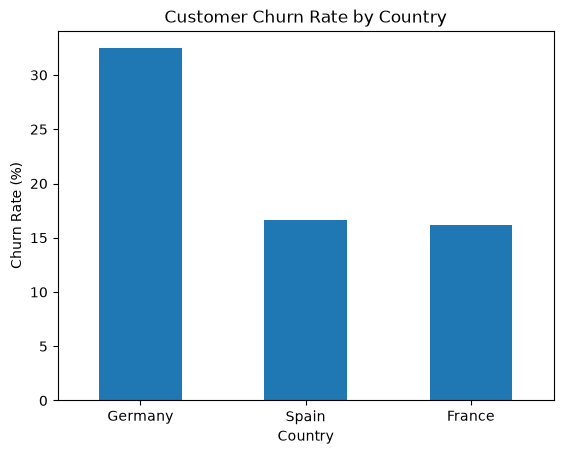

In [117]:
import matplotlib.pyplot as plt

churn_by_country = (
    df.groupby("Geography")["Exited"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

churn_by_country.plot(kind="bar")

plt.title("Customer Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

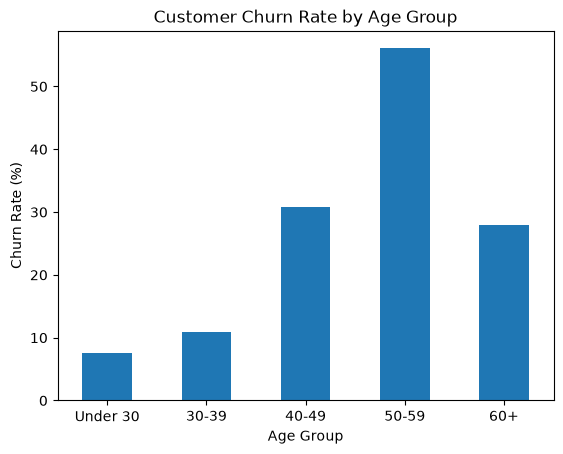

In [118]:
churn_by_age = (
    df.groupby("AgeGroup", observed=True)["Exited"]
      .mean()
      .mul(100)
)

churn_by_age.plot(kind="bar")

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

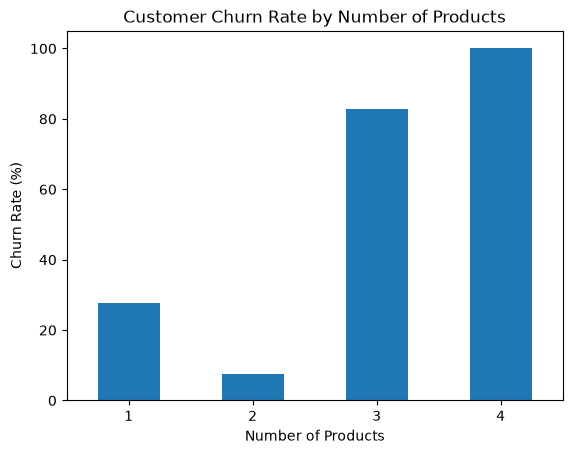

In [119]:
churn_by_products = (
    df.groupby("NumOfProducts")["Exited"]
      .mean()
      .mul(100)
)

churn_by_products.plot(kind="bar")

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [120]:
total_customers = len(df)
churned_customers = df["Exited"].sum()
churn_rate = df["Exited"].mean() * 100

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers: 10,000
Churned Customers: 2,037
Overall Churn Rate: 20.37%


In [121]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Output path
output_path = PROJECT_ROOT / "data" / "processed" / "bank_churn_processed.csv"

# Save processed dataset
df.to_csv(output_path, index=False)

print("Processed dataset saved successfully!")
print(f"Location: {output_path}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Processed dataset saved successfully!
Location: c:\Users\kavya\Data_Analysis\bank-customer-churn-analysis\data\processed\bank_churn_processed.csv
Rows: 10000
Columns: 15


In [122]:
processed_df = pd.read_csv(output_path)

print(processed_df.shape)
print(processed_df["AgeGroup"].value_counts().sort_index())

(10000, 15)
AgeGroup
30-39       4346
40-49       2618
50-59        869
60+          526
Under 30    1641
Name: count, dtype: int64


## Key Findings

1. The overall customer churn rate is 20.37%.

2. Inactive customers have a substantially higher churn rate
   than active customers (26.85% vs. 14.27%).

3. Germany has the highest churn rate at 32.44%,
   compared with approximately 16% in France and Spain.

4. Female customers have a higher churn rate than male customers
   (25.07% vs. 16.46%).

5. Customers aged 50–59 have the highest churn rate at 56.21%.

6. Customers with three or four products show exceptionally high
   churn rates, although these groups have relatively few customers.

7. Churned customers have a higher average balance than retained
   customers.

8. A segment of 460 German customers was identified as both
   inactive and above the median balance, with a combined balance
   of approximately $57.18 million.